<a href="https://colab.research.google.com/github/eliastche/PythonLabs/blob/main/Python_for_finance_Exam_FIT_MSC_2024.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Before you start
* Deactivate any generative AI assistance tool:
  * Go to Tools
  * Go to Settings
  * Go to AI Assistance
  * Tick the box "Hide generative AI features"

You will be penalized if you start the test with generative AI features enabled. Let me know if you need help.


# Exam duration : 2h30

# Part 1 : programming exercises (6 points)

### Exercise 1 (1 point)
* Write a function that takes the lengths of three sides of a triangle and checks whether it is a valid triangle. A triangle is valid if the sum of any two sides is greater than the third side.

In [5]:
def trainglecheck(a,b,c):
  return (a + b > c) and (a + c > b) and (b + c > a)

print(trainglecheck(2,3,4))

True


### Exercise 2 (2.5 points)
* Write a function that calculates the sum of the squares of all even numbers between 1 and 50 using a loop. The function should return that sum.

In [10]:
def squaresum():
  i = 1
  sum = 0
  while i <= 50:
    if i%2==0:
      square = i**2
      sum += square
    i += 1

  return sum

print(squaresum())




22100


### Exercise 3 (2.5 points)

* Write a function to implement the Collatz sequence: start with a positive integer n (parameter of the function). If n is even, divide it by 2; if n is odd, multiply it by 3 and add 1. Continue the process until n becomes 1. Print all the values of n during the process.

In [19]:
def collatz(n):
  while n != 1:
    if n%2==0:
      n=n//2
    else:
      n = n*3+1
    print(n)

collatz(27)



82
41
124
62
31
94
47
142
71
214
107
322
161
484
242
121
364
182
91
274
137
412
206
103
310
155
466
233
700
350
175
526
263
790
395
1186
593
1780
890
445
1336
668
334
167
502
251
754
377
1132
566
283
850
425
1276
638
319
958
479
1438
719
2158
1079
3238
1619
4858
2429
7288
3644
1822
911
2734
1367
4102
2051
6154
3077
9232
4616
2308
1154
577
1732
866
433
1300
650
325
976
488
244
122
61
184
92
46
23
70
35
106
53
160
80
40
20
10
5
16
8
4
2
1


# Part 2 : Data analysis and manipulation (10 points)


### 1. Load some stocks information into a pandas DataFrame (1 point)
* Using the yfinance module, download the Apple stocks (ticker 'AAPL') in a DataFrame

In [22]:
import yfinance as yf

stock = yf.download("AAPL")

apple_stock = stock.xs("AAPL", level=1, axis=1)

apple_stock.columns

/tmp/ipython-input-3505439954.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download("AAPL")
[*********************100%***********************]  1 of 1 completed


Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

### 2. Data analysis (4 points)
First two questions : justify your answers by writing down and executing the code that helped you answer the question.

* a. What is the first date in that DataFrame ? (1 point)
* b. What is the last date in that DataFrame ? (1 point)
* c. Plot the High column as a function of time using seaborn (1 points)
* d. Plot a histogram of the Close column
(1 points)


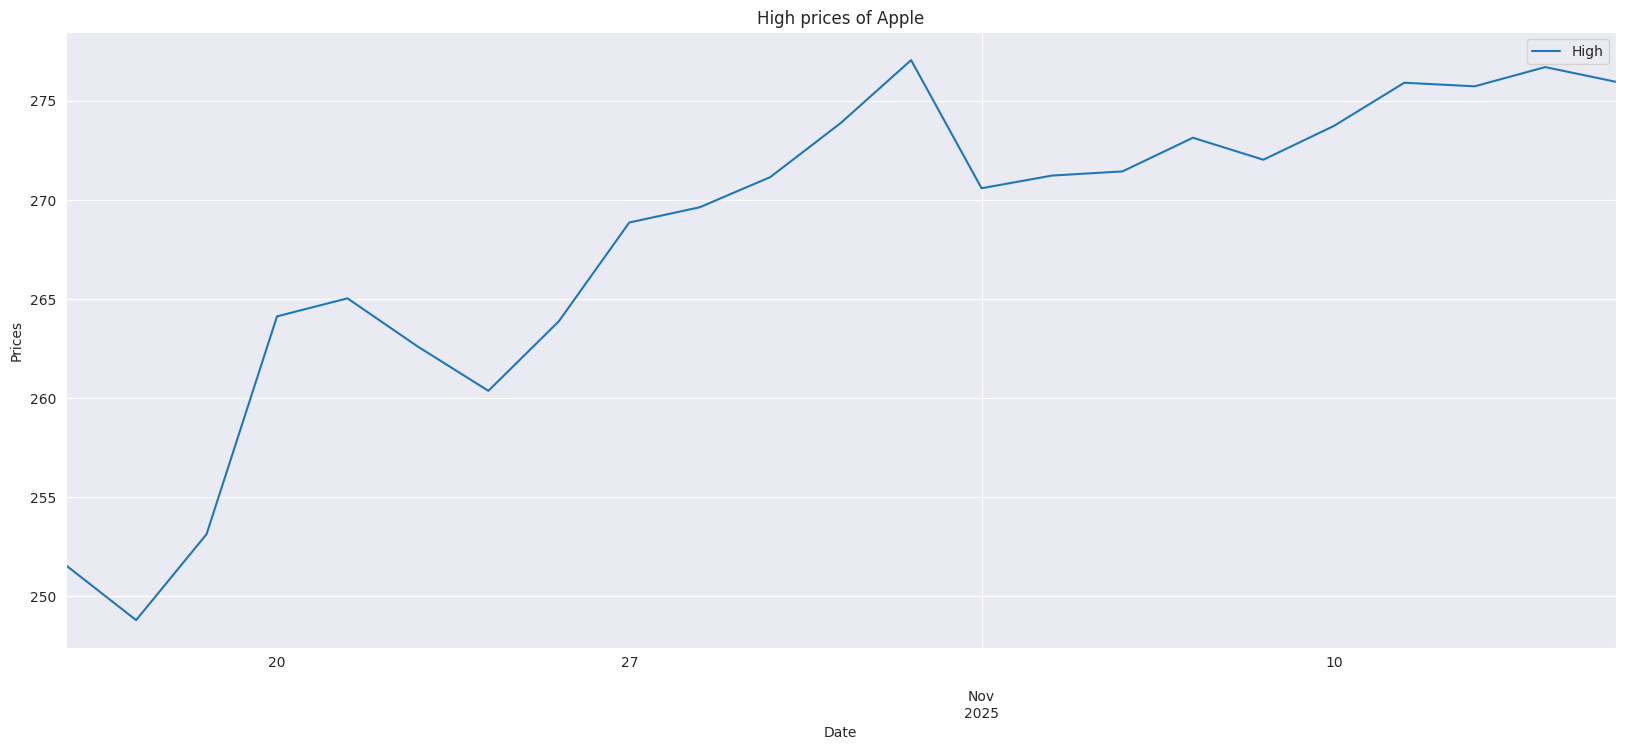

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt


#a & b
apple_stock.head().index[1]
apple_stock.tail().index[1]

#c
apple_stock[['High']].plot(figsize=(20, 8),title="High prices of Apple",)

plt.xlabel("Date")
plt.ylabel("Prices")
plt.legend(['High'])
sns.set_style("darkgrid")


<Axes: xlabel='Close', ylabel='Count'>

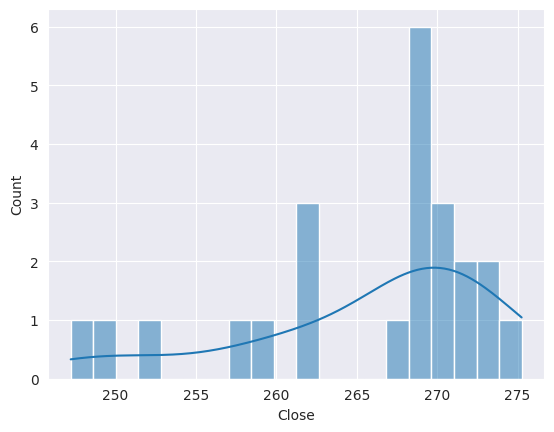

In [32]:
#d
sns.histplot(apple_stock["Close"].dropna(), bins=20, kde=True)

### 3. Data manipulation (5 points)
* **a. Daily return.** Add a column 'Daily Return' to the DataFrame. That column should contain the daily return value (i.e. the change in percentage from one day to the next). Compute these values by calculating a percentage change on the Close column. (1 point)
* **b. Average true range.** Add a column 'ATR' to the DataFrame. Values in that column should be the average true range: the average range of price movement over a period. To achieve this: compute the difference between 'High' and 'Low' columns and store this data in a new column. Then, compute the ATR using this new column by calculating the moving average over a period of 10 days. You can compute a moving average by successively applying the functions rolling() and mean() to some column. (2 points)
* **c. Price momentum.** Add a column 'Price Momentum' to the DataFrame. This column should contain the closing price difference between a day and 10 days earlier. You can use df[some_column].shift(1) to get the value of a column at the line before.  (2 points)

In [41]:
apple_stock["Daily Return"] = apple_stock["Close"].pct_change()

apple_stock["ATR"] = apple_stock["High"] - apple_stock["Low"]

apple_stock["ATR"] = apple_stock["ATR"].rolling(10).mean()

apple_stock["Price Momentum"] = apple_stock["Close"] - apple_stock["Close"].shift(10)

apple_stock.head(12)

Price,Close,High,Low,Open,Volume,Daily Return,ATR,Price Momentum
Date,,,,,,,,
2025-10-15,249.098526,251.576135,247.230342,249.248390,33893600,NaN,NaN,NaN
2025-10-16,247.210358,248.798814,244.892612,248.009586,39777000,-0.007580,NaN,NaN
2025-10-17,252.045654,253.134610,247.030527,247.779801,49147000,0.019559,NaN,NaN
2025-10-20,261.986023,264.123965,255.382439,255.642182,90483000,0.039439,NaN,NaN
2025-10-21,262.515503,265.033082,261.576411,261.626381,46695900,0.002021,NaN,NaN
2025-10-22,258.199707,262.595440,255.182612,262.395621,45015300,-0.016440,NaN,NaN
2025-10-23,259.328583,260.367584,257.760126,259.688250,32754900,0.004372,NaN,NaN
2025-10-24,262.565491,263.874220,258.929001,260.937064,38253700,0.012482,NaN,NaN
2025-10-27,268.549652,268.859349,264.393677,264.623466,44888200,0.022791,NaN,NaN
